# Analiza i Klasifikacija Fetalnog Zdravlja
### Fetal Health Dataset — Predikcija stanja fetusa pomocu nadgledanog ucenja

---
> **Autor:** Aleksandra Djokic  
> **Predmet:** Masinsko ucenje  
> **Dataset:** Fetal Health (2,126 uzoraka)
## 1. Uvod

Cilj mog projekta je predvideti klasu zdravlja fetusa na osnovu CTG parametara. Klasifikacija se vrši u tri kategorije:
1.  **Normalno (Normal)**
2.  **Sumnjivo (Suspect)**
3.  **Patološko (Pathological)**

Podaci obuhvataju različite parametre izmerene tokom pregleda, uključujući:

*   **osnovnu frekvenciju srca (baseline value)**,
*   **ubrzanja (accelerations)**,
*   **pokrete fetusa (fetal movement)**,
*   **kontrakcije materice (uterine contractions)**,
*   **usporenja srca** (blaga, teška i produžena),
*   **varijabilnost** (kratkoročnu i dugoročnu),
*   **histogramske podatke** (širina, minimum, maksimum, mod, srednja vrednost, tendencija).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:

CSV_PATH = "fetal_health.csv" 

data = pd.read_csv(CSV_PATH) 

display(data.head()) 


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


Ova tabela pruža uvid u prvih 5 redova našeg skupa podataka, omogućavajući nam da vidimo strukturu i vrednosti različitih CTG parametara

In [3]:
# Prikaz informacija o strukturi podataka
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability             

In [4]:
data.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


## Analiza strukture podataka

- **Broj uzoraka (count):** Dataset sadrži ukupno 2126 unosa (redova). Za sve kolone, broj unosa je takođe 2126, što znači da nema nedostajućih vrednosti (Null). 

- **Tipovi podataka (Dtype):** Sve kolone su tipa `float64` (numeričke vrednosti).

In [5]:
transposed_stats = data.describe().T
transposed_stats

,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0,133.303857,9.840844,106.0,126.000,133.000,140.000,160.000
accelerations,2126.0,0.003178,0.003866,0.0,0.000,0.002,0.006,0.019
fetal_movement,2126.0,0.009481,0.046666,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2126.0,0.004366,0.002946,0.0,0.002,0.004,0.007,0.015
light_decelerations,2126.0,0.001889,0.002960,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2126.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2126.0,0.000159,0.000590,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2126.0,46.990122,17.192814,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2126.0,1.332785,0.883241,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2126.0,9.846660,18.396880,0.0,0.000,0.000,11.000,91.000


## Čišćenje podataka

Proveravamo da li postoje duplikati.

In [6]:
print(f"Broj duplikata: {data.duplicated().sum()}")
if data.duplicated().sum() > 0:
    data = data.drop_duplicates()
print(f"Novi oblik podataka: {data.shape}")

Broj duplikata: 13
Novi oblik podataka: (2113, 22)


## Kodiranje podataka

Svi podaci su već numerički. Ciljna promenljiva 'fetal_health' je tipa float. Konverzija u int radi lakšeg rada.


In [7]:
data['fetal_health'] = data['fetal_health'].astype(int)
data.info()

<class 'pandas.DataFrame'>
Index: 2113 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2113 non-null   float64
 1   accelerations                                           2113 non-null   float64
 2   fetal_movement                                          2113 non-null   float64
 3   uterine_contractions                                    2113 non-null   float64
 4   light_decelerations                                     2113 non-null   float64
 5   severe_decelerations                                    2113 non-null   float64
 6   prolongued_decelerations                                2113 non-null   float64
 7   abnormal_short_term_variability                         2113 non-null   float64
 8   mean_value_of_short_term_variability                  

In [8]:
data.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,...,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000
mean,133.304780,0.003188,0.009517,0.004387,0.001901,0.000003,0.000159,46.993848,1.335021,9.795078,...,93.564600,164.099858,4.077142,0.325603,137.454330,134.599621,138.089446,18.907241,0.318504,1.303833
std,9.837451,0.003871,0.046804,0.002941,0.002966,0.000057,0.000592,17.177782,0.884368,18.337073,...,29.562269,17.945175,2.951664,0.707771,16.402026,15.610422,14.478957,29.038766,0.611075,0.614279
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.000000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.005000,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,...,93.000000,162.000000,4.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.000000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.000000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


## 2. Eksploratorna analiza podataka (EDA)

 U ovom delu ćemo vizualizovati distribuciju klasa, analizirati korelacije između promenljivih i identifikovati potencijalne outliere.

Kreiranje grafikona za analizu distribucije podataka i odnosa između faktora rizika. Prvo ćemo proveriti balans klasa u ciljnoj promenljivoj 'fetal_health'.

In [9]:
print(data["fetal_health"].value_counts())
print(data["fetal_health"].value_counts(normalize=True) * 100)

fetal_health
1    1646
2     292
3     175
Name: count, dtype: int64
fetal_health
1    77.898722
2    13.819214
3     8.282063
Name: proportion, dtype: float64


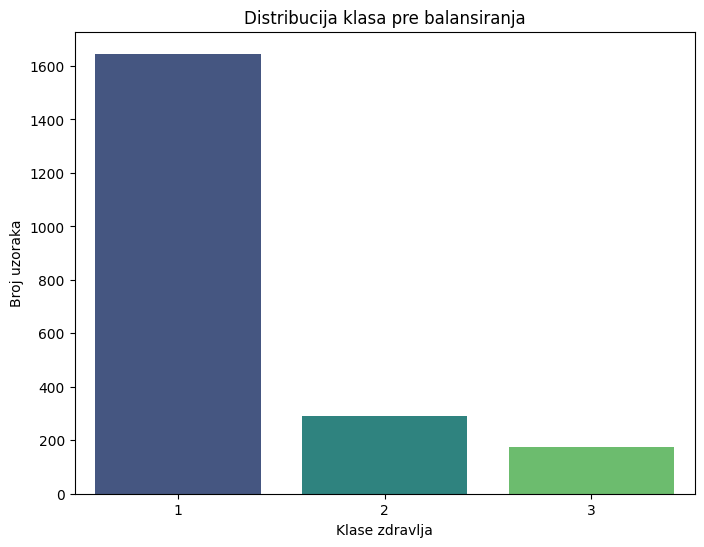

In [10]:
plt.figure(figsize=(8, 6))
sns.countplot(x="fetal_health", data=data, palette="viridis")
plt.title("Distribucija klasa pre balansiranja")
plt.xlabel("Klase zdravlja")
plt.ylabel("Broj uzoraka")
plt.show()

### Analiza distribucije klasa

Distribucija klasa pokazuje da je klasa 1 (Normal) dominantna, sa približno 78% uzoraka, dok su klase 2 (Sumnjivo) i 3 (Patološko) u manjini. 

Da bismo rešili ovaj problem, koristićemo tehniku **SMOTE (Synthetic Minority Over-sampling Technique)** za balansiranje klasa pre modelovanja.

### Podela podataka (pre preprocesiranja)


In [11]:
from sklearn.model_selection import train_test_split
from collections import Counter

X = data.drop("fetal_health", axis=1)
y = data["fetal_health"]

# Podela pre bilo kakvog preprocesiranja
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Oblik trening skupa:", X_train_raw.shape, y_train_raw.shape)
print("Oblik test skupa:", X_test_raw.shape, y_test_raw.shape)
print("Balans klasa u trening skupu:", Counter(y_train_raw))
print("Balans klasa u test skupu:", Counter(y_test_raw))


Oblik trening skupa: (1690, 21) (1690,)
Oblik test skupa: (423, 21) (423,)
Balans klasa u trening skupu: Counter({1: 1316, 2: 234, 3: 140})
Balans klasa u test skupu: Counter({1: 330, 2: 58, 3: 35})


In [12]:
# Balansirani trening set se cuva nakon SMOTE-a (videti sekciju Balansiranje klasa)
print("Podela podataka zavrsena.")


Podela podataka zavrsena.


## Vizuelizacija podataka (Histogrami)

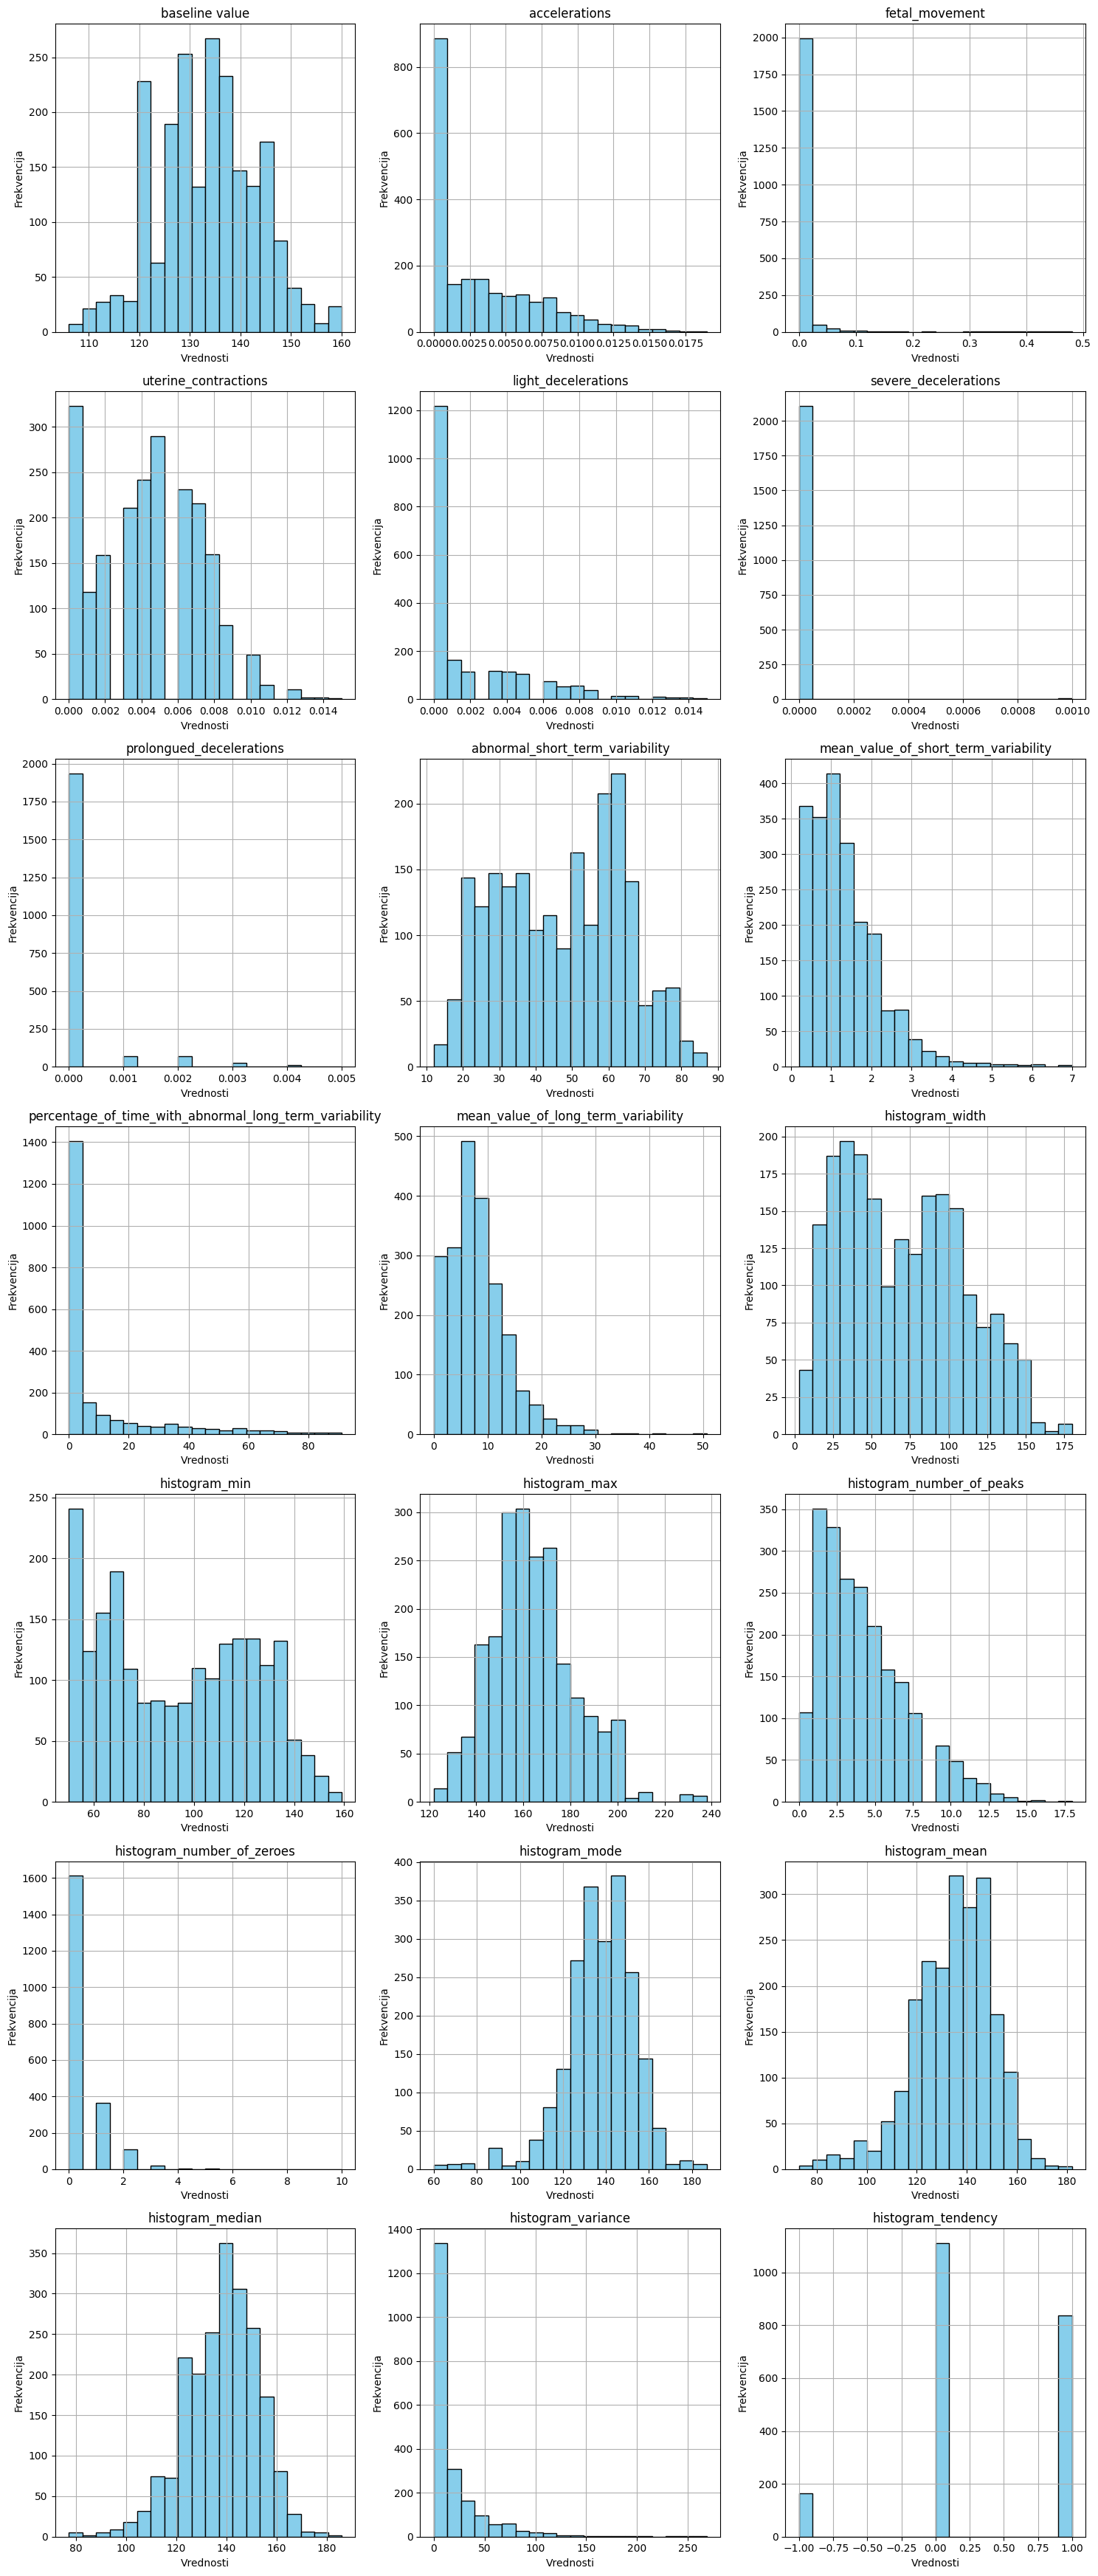

In [13]:
numerical_columns = data.columns[data.columns != 'fetal_health']

def drow_hist_for_num_columns(data, numerical_columns):
    import math
    import matplotlib.pyplot as plt

    NUM_COLUMNS = 3
    NUM_ROWS = math.ceil(len(numerical_columns) / NUM_COLUMNS)

    fig, axes = plt.subplots(NUM_ROWS, NUM_COLUMNS, figsize=(15, 5 * NUM_ROWS))
    axes = axes.flatten()

    for i, column in enumerate(numerical_columns):
        data[column].hist(ax=axes[i], bins=20, color='skyblue', edgecolor='black')
        axes[i].set_title(column)
        axes[i].set_xlabel('Vrednosti')
        axes[i].set_ylabel('Frekvencija')

    # Uklanjanje praznih podgrafikona
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Poziv funkcije za crtanje histograma za sve numericke kolone
drow_hist_for_num_columns(data, numerical_columns)

##  Analiza Outliera (Boxplotovi)


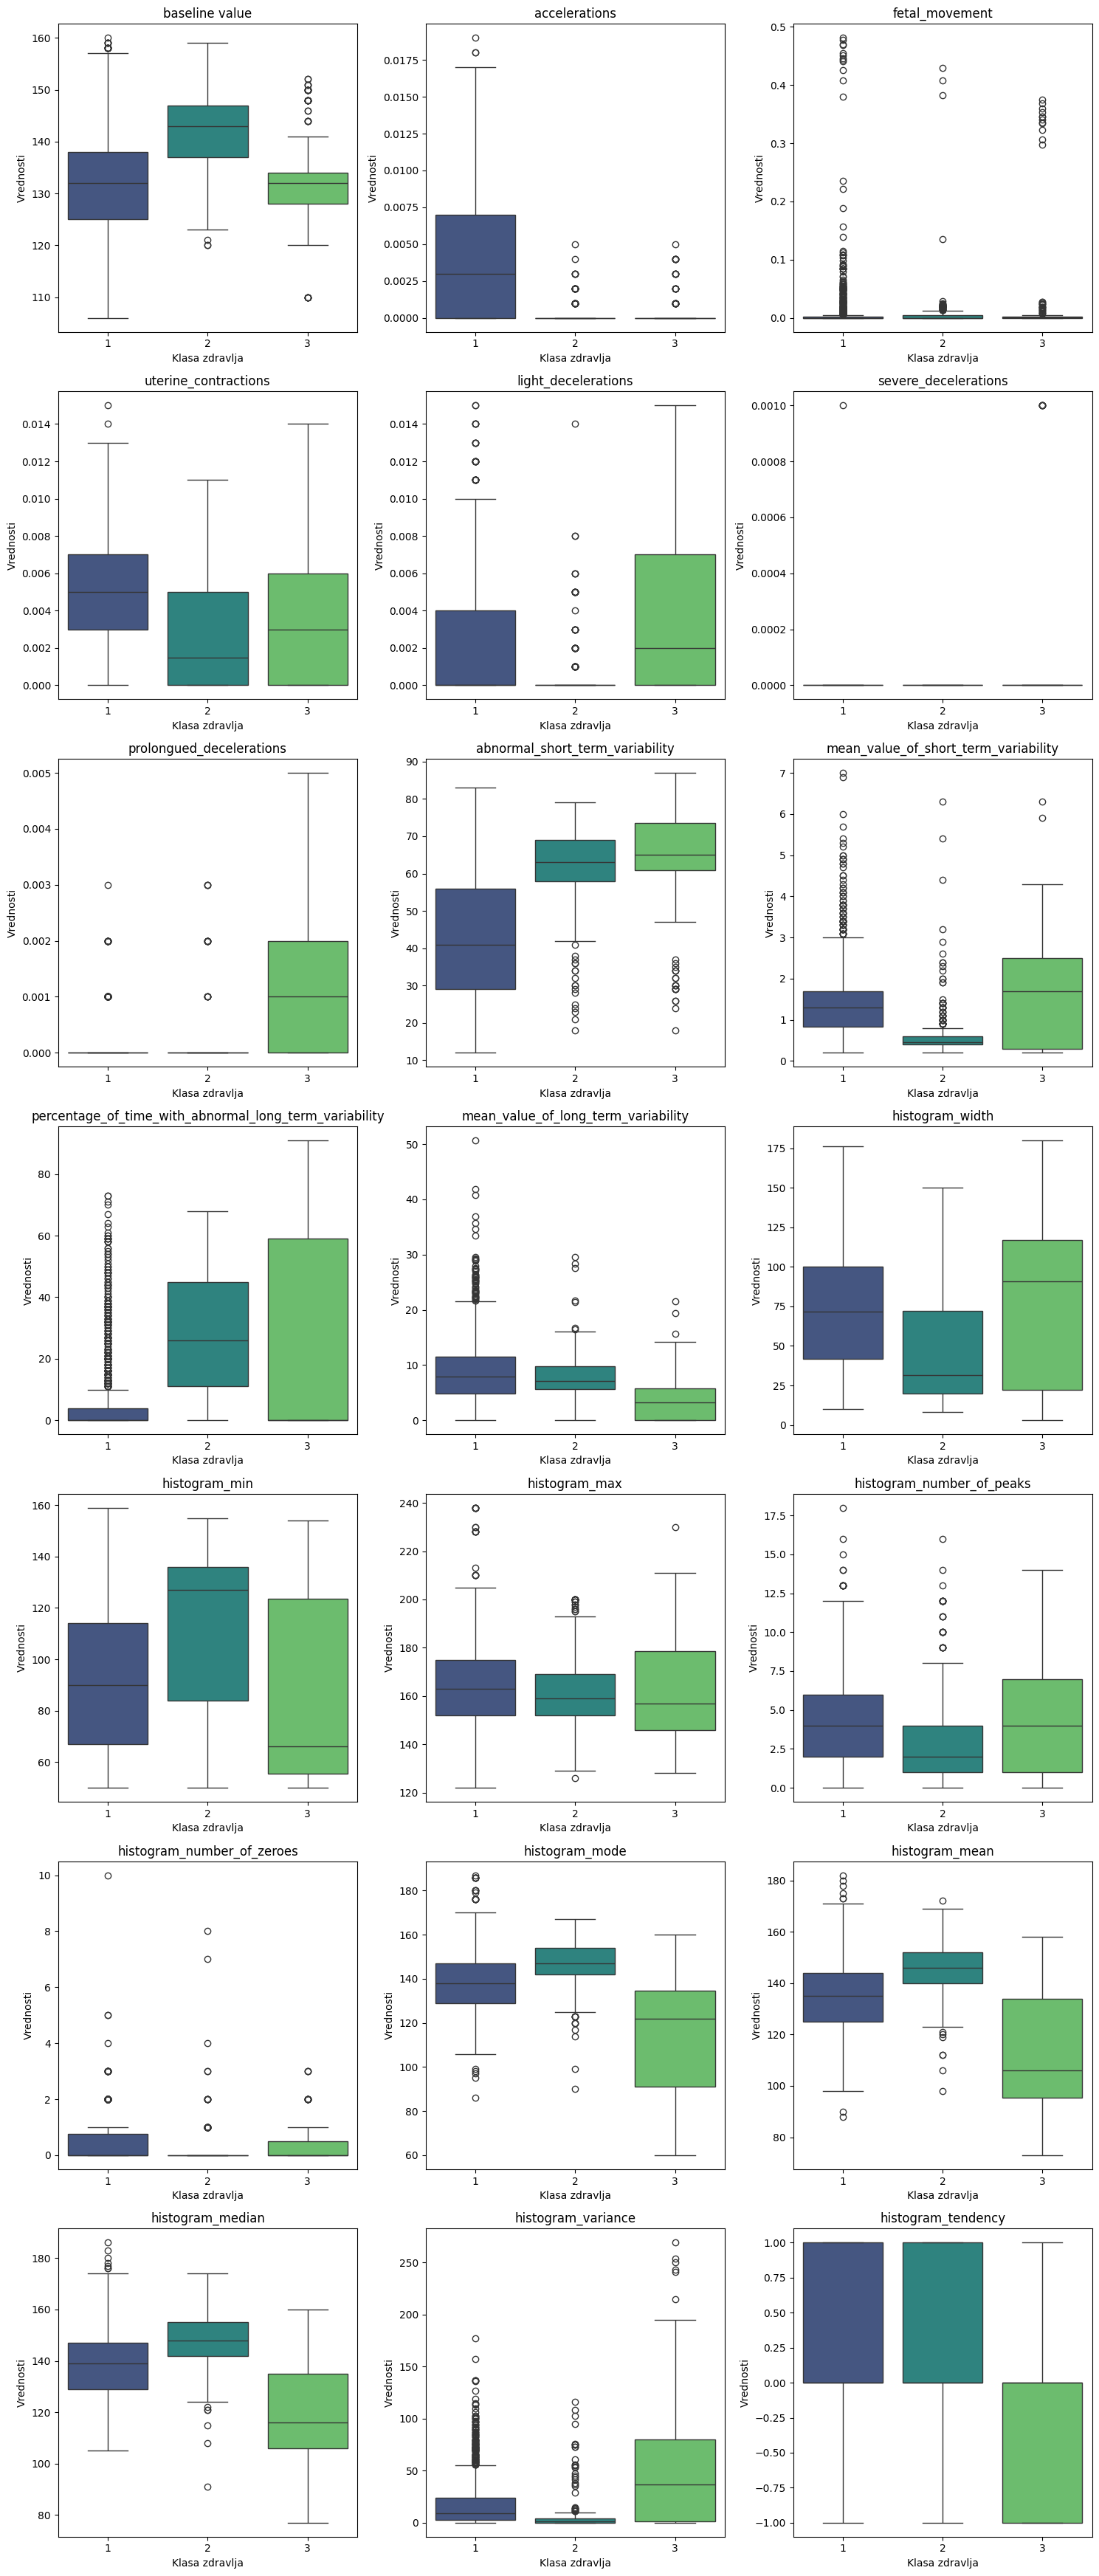

In [14]:
import math
def drow_box_for_num_column(data, numerical_columns):
    import matplotlib.pyplot as plt
    import seaborn as sns

    NUM_COLUMNS = 3
    NUM_ROWS = math.ceil(len(numerical_columns) / NUM_COLUMNS)

    fig, axes = plt.subplots(NUM_ROWS, NUM_COLUMNS, figsize=(15, 5 * NUM_ROWS))
    axes = axes.flatten()

    for i, column in enumerate(numerical_columns):
        sns.boxplot(data=data, x='fetal_health', y=column, ax=axes[i], palette="viridis")
        axes[i].set_title(column)
        axes[i].set_xlabel('Klasa zdravlja')
        axes[i].set_ylabel('Vrednosti')

    # Uklanjanje praznih podgrafikona
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

def plot_one_boxplot(data, column):
    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.boxplot(data=data, x='fetal_health', y=column, palette="viridis")
    plt.title(f"Boxplot za kolonu: {column}")
    plt.xlabel('Klasa zdravlja')
    plt.ylabel('Vrednosti')
    plt.show()

    stats = data[column].describe()
    print(f"Statistika za kolonu {column}:")
    print(f"Min: {stats['min']}")
    print(f"Q1: {stats['25%']}")
    print(f"Median: {stats['50%']}")
    print(f"Q3: {stats['75%']}")
    print(f"Max: {stats['max']}")

drow_box_for_num_column(data, numerical_columns)

##  Korelacija

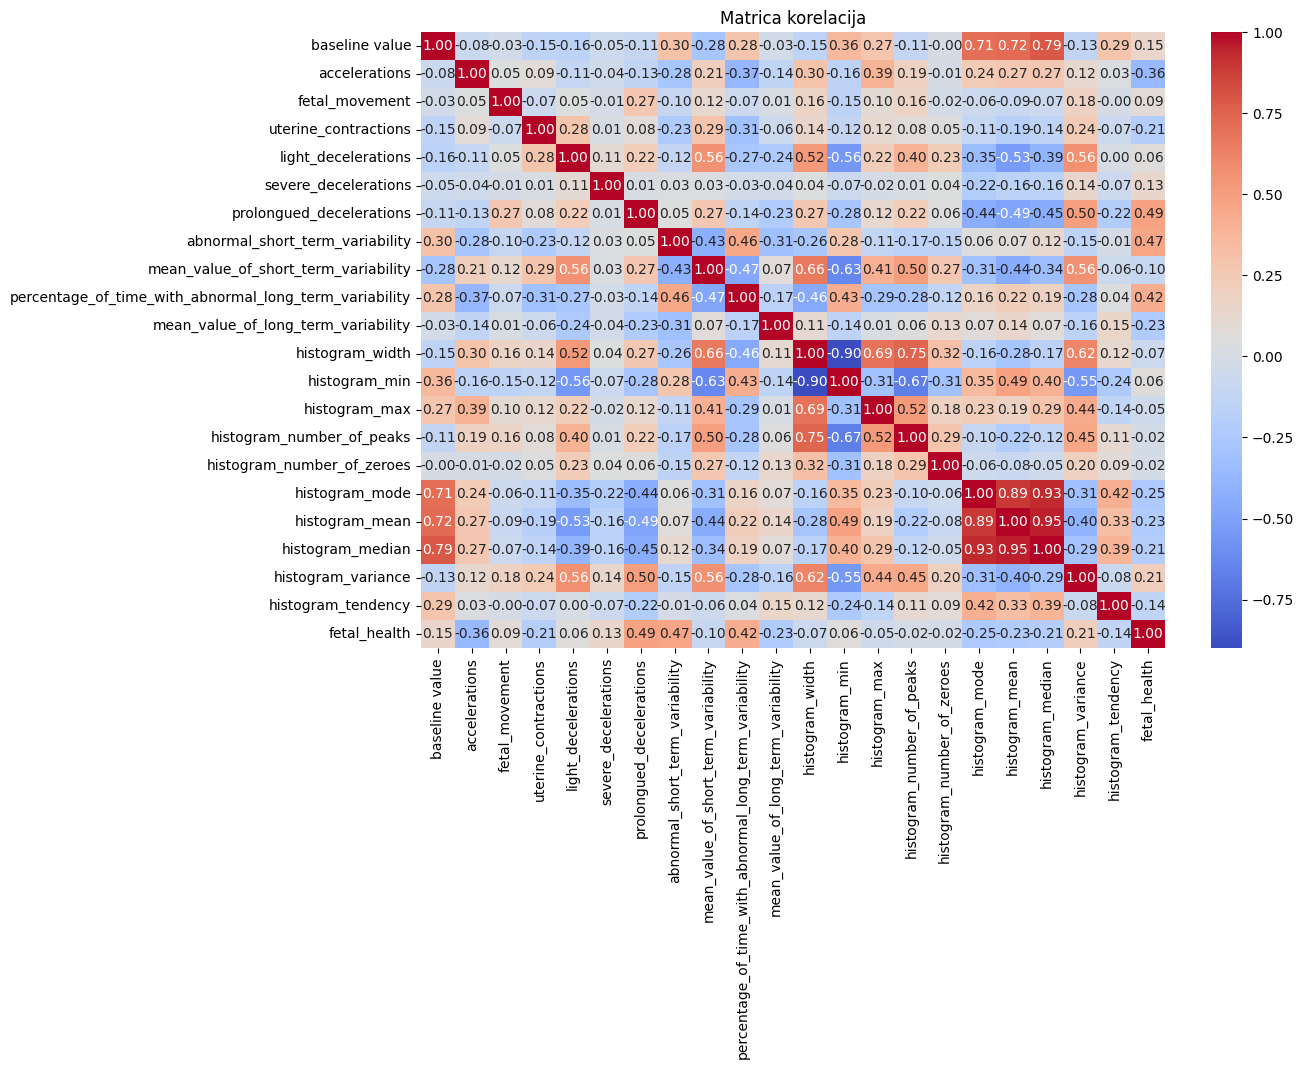

In [15]:

correlation_matrix = data.corr()

# Vizualizacija korelacione matrice pomoću heatmap-a
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matrica korelacija")
plt.show()

## 3. Priprema za modelovanje


## Brisanje/Tretiranje outlier-a

Identifikujemo ekstremne vrednosti koristeći IQR metodu i primenjujemo Winsorization (zamenu ekstremnih vrednosti granicama) kako bismo poboljšali tačnost modela.

In [16]:
def detect_outliers(data, features):
    outliers = {}
    for feature in features:
        Q1 = data[feature].quantile(0.25)
        Q3 = data[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers[feature] = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)][feature]
    return outliers

outliers_detected = detect_outliers(X_train_raw, numerical_columns)
print("Detektovani outlieri (samo na trening skupu):")
for feature, outlier_values in outliers_detected.items():
    print(f"{feature}: {len(outlier_values)} outliera")


def compute_winsorize_bounds(train_data, features, factor=1.5):
    bounds = {}
    for feature in features:
        Q1 = train_data[feature].quantile(0.25)
        Q3 = train_data[feature].quantile(0.75)
        IQR = Q3 - Q1
        bounds[feature] = (Q1 - factor * IQR, Q3 + factor * IQR)
    return bounds

def apply_winsorize(data, bounds):
    data_w = data.copy()
    for feature, (lower, upper) in bounds.items():
        data_w[feature] = data[feature].clip(lower=lower, upper=upper)
    return data_w

win_bounds = compute_winsorize_bounds(X_train_raw, numerical_columns)
X_train_winsorized = apply_winsorize(X_train_raw, win_bounds)
X_test_winsorized = apply_winsorize(X_test_raw, win_bounds)
print("Winsorization primenjen (granice naucene samo na trening skupu).")


Detektovani outlieri (samo na trening skupu):
baseline value: 0 outliera
accelerations: 13 outliera
fetal_movement: 254 outliera
uterine_contractions: 1 outliera
light_decelerations: 109 outliera
severe_decelerations: 7 outliera
prolongued_decelerations: 148 outliera
abnormal_short_term_variability: 0 outliera
mean_value_of_short_term_variability: 54 outliera
percentage_of_time_with_abnormal_long_term_variability: 247 outliera
mean_value_of_long_term_variability: 56 outliera
histogram_width: 0 outliera
histogram_min: 0 outliera
histogram_max: 16 outliera
histogram_number_of_peaks: 13 outliera
histogram_number_of_zeroes: 394 outliera
histogram_mode: 59 outliera
histogram_mean: 36 outliera
histogram_median: 23 outliera
histogram_variance: 142 outliera
histogram_tendency: 0 outliera
Winsorization primenjen (granice naucene samo na trening skupu).


##  Standardizacija


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_winsorized),
    columns=X_train_winsorized.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_winsorized),
    columns=X_test_winsorized.columns
)
print(X_train_scaled.head())


   baseline value  accelerations  fetal_movement  uterine_contractions  \
0       -0.121468      -0.567505       -0.641508              0.219852   
1       -0.528973       1.259321        2.016586             -0.465348   
2       -0.325220      -0.828481        2.016586              1.247653   
3        0.999171      -0.828481       -0.641508             -0.807949   
4        1.101047      -0.828481       -0.641508             -1.493149   

   light_decelerations  severe_decelerations  prolongued_decelerations  \
0             1.335748                   0.0                       0.0   
1             1.335748                   0.0                       0.0   
2            -0.684310                   0.0                       0.0   
3            -0.684310                   0.0                       0.0   
4            -0.684310                   0.0                       0.0   

   abnormal_short_term_variability  mean_value_of_short_term_variability  \
0                        -0.969271

##  Feature selection

Odabir najvažnijih karakteristika koriscenjem ANOVA (f_classif) test za identifikaciju.

In [18]:
def feature_selections(score_func, X_train, y_train, X_test, k):
    from sklearn.feature_selection import SelectKBest
    selector = SelectKBest(score_func=score_func, k=k)
    X_train_new = selector.fit_transform(X_train, y_train)
    X_test_new = selector.transform(X_test)
    scores = selector.scores_
    columns = X_train.columns[selector.get_support(indices=True)]
    return X_train_new, X_test_new, scores, columns

from sklearn.feature_selection import f_classif
X_train_top10, X_test_top10, scores, top_columns = feature_selections(
    f_classif, X_train_scaled, y_train_raw, X_test_scaled, k=10
)

scores_table = pd.DataFrame({"Feature": X_train_scaled.columns, "Score": scores}).sort_values(by="Score", ascending=False)
print("Top 10 karakteristika (odabrano samo na osnovu trening skupa):")
print(scores_table.head(10))

X_train_top10 = pd.DataFrame(X_train_top10, columns=top_columns)
X_test_top10 = pd.DataFrame(X_test_top10, columns=top_columns)
print(X_train_top10.head())


Top 10 karakteristika (odabrano samo na osnovu trening skupa):
                                              Feature       Score
9   percentage_of_time_with_abnormal_long_term_var...  330.788403
7                     abnormal_short_term_variability  284.950181
17                                     histogram_mean  218.302323
18                                   histogram_median  185.041162
16                                     histogram_mode  164.352990
1                                       accelerations  162.283536
8                mean_value_of_short_term_variability  133.857044
0                                      baseline value  103.508815
19                                 histogram_variance   93.424713
3                                uterine_contractions   81.384411
   baseline value  accelerations  uterine_contractions  \
0       -0.121468      -0.567505              0.219852   
1       -0.528973       1.259321             -0.465348   
2       -0.325220      -0.828481     

##  Balansiranje klasa i SMOTE


In [19]:
# Prilagodjavanje ciljne promenljive za pocetak od 0 (kompatibilnost sa XGBoostom)
y_train_shifted = y_train_raw - 1
y_test_shifted = y_test_raw - 1

print("Oblik trening skupa:", X_train_top10.shape, y_train_shifted.shape)
print("Oblik test skupa:", X_test_top10.shape, y_test_shifted.shape)


Oblik trening skupa: (1690, 10) (1690,)
Oblik test skupa: (423, 10) (423,)


In [20]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train_top10, y_train_shifted)
X_test = X_test_top10.copy()
y_test = y_test_shifted.copy()

balanced_train_df = pd.DataFrame(X_train, columns=top_columns)
balanced_train_df["fetal_health"] = y_train + 1
balanced_train_df.to_csv("fetal_health_balanced_train.csv", index=False)

print("Balans klasa u originalnom trening skupu:", Counter(y_train_shifted))
print("Balans klasa u trening skupu NAKON SMOTE-a:", Counter(y_train))
print("Balans klasa u test skupu:", Counter(y_test))
print("Uspesno kreiran balansirani trening set.")


Balans klasa u originalnom trening skupu: Counter({0: 1316, 1: 234, 2: 140})
Balans klasa u trening skupu NAKON SMOTE-a: Counter({0: 1316, 1: 1316, 2: 1316})
Balans klasa u test skupu: Counter({0: 330, 1: 58, 2: 35})
Uspesno kreiran balansirani trening set.


## 4. Redukcija dimenzionalnosti (PCA)


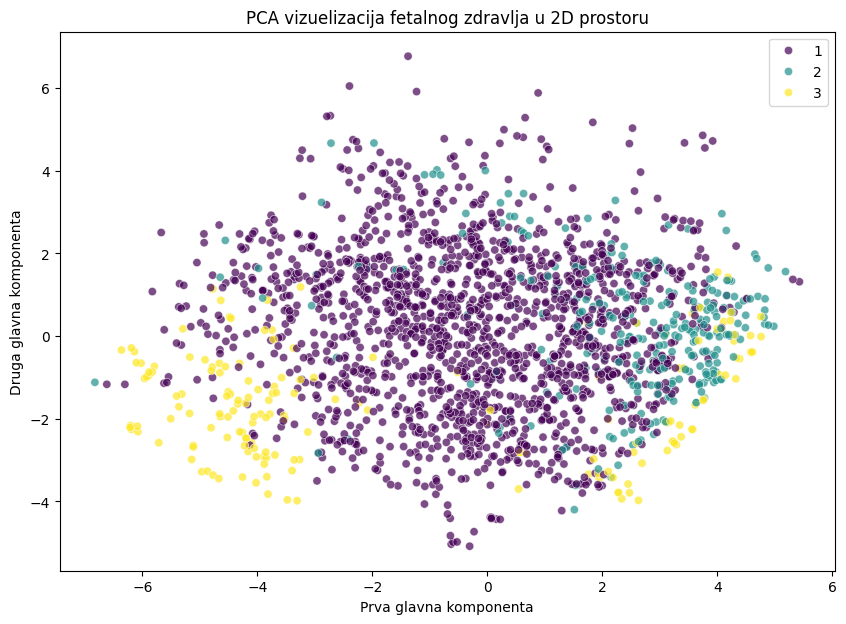

In [21]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=2, random_state=42)

# PCA fit samo na trening skupu, pa transformacija i train i test (bez leakage-a)
X_train_pca = pca.fit_transform(X_train_scaled.values)
X_test_pca = pca.transform(X_test_scaled.values)

X_pca = np.vstack([X_train_pca, X_test_pca])
y_all = np.concatenate([y_train_raw.values, y_test_raw.values])

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_all, palette="viridis", alpha=0.7)
plt.title("PCA vizuelizacija fetalnog zdravlja u 2D prostoru")
plt.xlabel("Prva glavna komponenta")
plt.ylabel("Druga glavna komponenta")
plt.show()

PCA nam pokazuje u kojoj meri se Normal, Suspect i Pathological klase preklapaju. Što su grupacije jasnije, to će model lakše donositi odluke.

## 5. Izbor i odluka modela

U ovom delu ćemo testirati različite algoritme za klasifikaciju i evaluirati njihove performanse koristeći metrike kao što su tačnost, preciznost, odziv i F1 skor.

In [22]:
def train_and_eval_my_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Treniranje modela
    model.fit(X_train, y_train)

    # Predikcija na test skupu
    y_pred = model.predict(X_test)

    # Evaluacija performansi
    print("Izveštaj o klasifikaciji:")
    print(classification_report(y_test, y_pred))
    acc = accuracy_score(y_test, y_pred)
    prec_w = precision_score(y_test, y_pred, average='weighted')
    rec_w = recall_score(y_test, y_pred, average='weighted')
    f1_w = f1_score(y_test, y_pred, average='weighted')
    f1_macro = f1_score(y_test, y_pred, average='macro')

    print("Tačnost:", acc)
    print("Preciznost (weighted):", prec_w)
    print("Odziv (weighted):", rec_w)
    print("F1 skor (weighted):", f1_w)
    print("F1 skor (macro):", f1_macro)

    # Matrica konfuzije kao figura
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Normal", "Suspect", "Pathological"],
        yticklabels=["Normal", "Suspect", "Pathological"],
        ax=ax
    )
    ax.set_xlabel("Predicted Labels")
    ax.set_ylabel("True Labels")
    ax.set_title(f"Matrica konfuzije - {model_name}")
    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision (Weighted)": prec_w,
        "Recall (Weighted)": rec_w,
        "F1-Score (Weighted)": f1_w,
        "F1-Score (Macro)": f1_macro
    }

Izveštaj o klasifikaciji:
              precision    recall  f1-score   support

           0       0.96      0.85      0.90       330
           1       0.48      0.72      0.58        58
           2       0.64      0.83      0.72        35

    accuracy                           0.83       423
   macro avg       0.69      0.80      0.73       423
weighted avg       0.87      0.83      0.84       423

Tačnost: 0.8274231678486997
Preciznost (weighted): 0.8693147337070056
Odziv (weighted): 0.8274231678486997
F1 skor (weighted): 0.8410044042877036
F1 skor (macro): 0.733447488584475


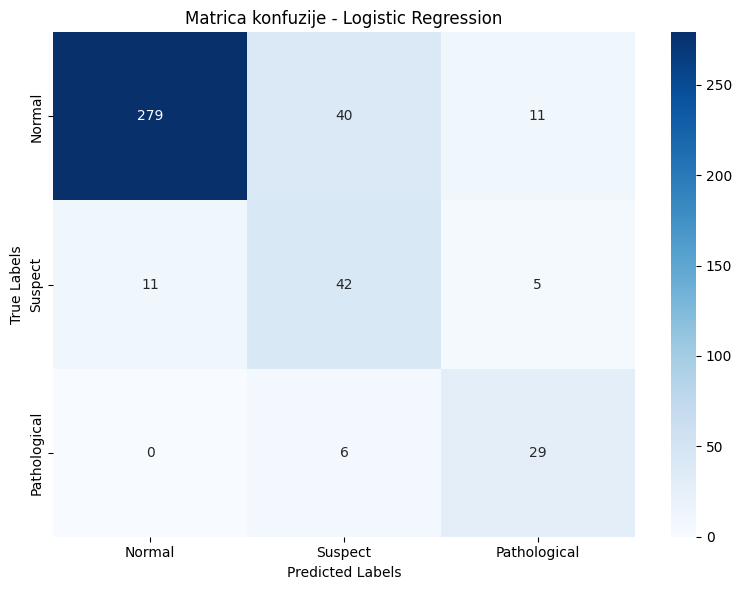

In [23]:
# Treniranje i evaluacija Logistic Regression (Baseline)
from sklearn.linear_model import LogisticRegression

model_results = []

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg_metrics = train_and_eval_my_model(
    log_reg, X_train, X_test, y_train, y_test, model_name="Logistic Regression"
 )
model_results.append(log_reg_metrics)

Izveštaj o klasifikaciji:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       330
           1       0.76      0.66      0.70        58
           2       0.88      0.86      0.87        35

    accuracy                           0.92       423
   macro avg       0.86      0.83      0.84       423
weighted avg       0.92      0.92      0.92       423

Tačnost: 0.9196217494089834
Preciznost (weighted): 0.915934347629719
Odziv (weighted): 0.9196217494089834
F1 skor (weighted): 0.9170950632938208
F1 skor (macro): 0.8443033922334631


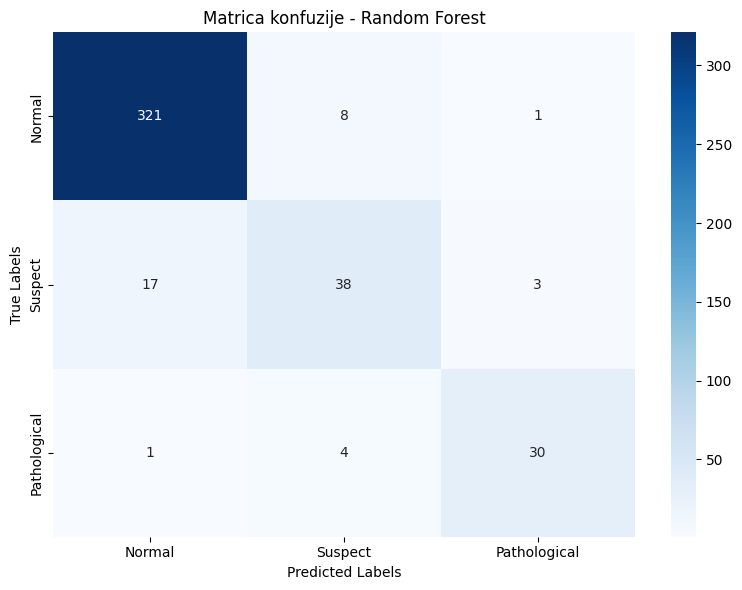

In [24]:
# Treniranje i evaluacija Random Forest
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(random_state=42, n_estimators=100)
rf_metrics = train_and_eval_my_model(
    random_forest, X_train, X_test, y_train, y_test, model_name="Random Forest"
 )
model_results.append(rf_metrics)

Izveštaj o klasifikaciji:
              precision    recall  f1-score   support

           0       0.98      0.87      0.92       330
           1       0.51      0.78      0.62        58
           2       0.64      0.77      0.70        35

    accuracy                           0.85       423
   macro avg       0.71      0.80      0.75       423
weighted avg       0.88      0.85      0.86       423

Tačnost: 0.8463356973995272
Preciznost (weighted): 0.8848111864414239
Odziv (weighted): 0.8463356973995272
F1 skor (weighted): 0.8588284467495496
F1 skor (macro): 0.7452916997322108


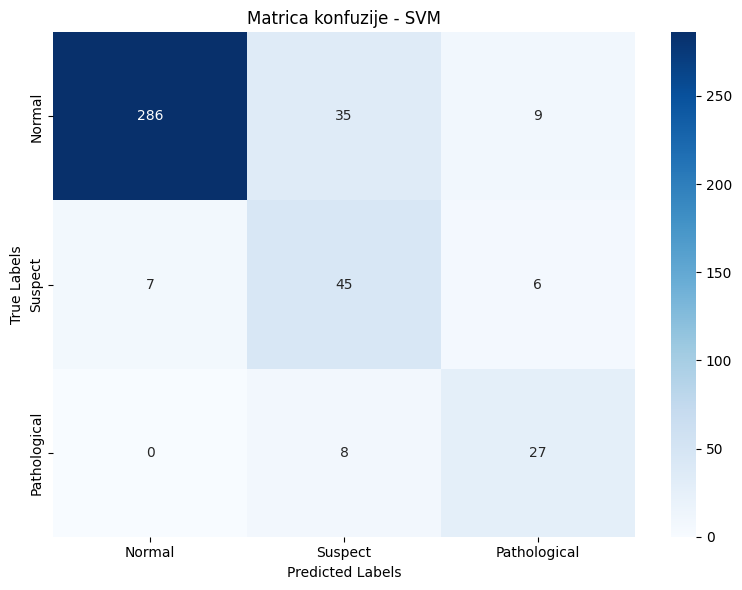

In [25]:
# Treniranje i evaluacija Support Vector Machines (SVM)
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_metrics = train_and_eval_my_model(
    svm_model, X_train, X_test, y_train, y_test, model_name="SVM"
 )
model_results.append(svm_metrics)

Izveštaj o klasifikaciji:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       330
           1       0.81      0.67      0.74        58
           2       0.85      0.80      0.82        35

    accuracy                           0.93       423
   macro avg       0.87      0.82      0.84       423
weighted avg       0.93      0.93      0.93       423

Tačnost: 0.9290780141843972
Preciznost (weighted): 0.9252562014320134
Odziv (weighted): 0.9290780141843972
F1 skor (weighted): 0.925960629133227
F1 skor (macro): 0.8432055212021915


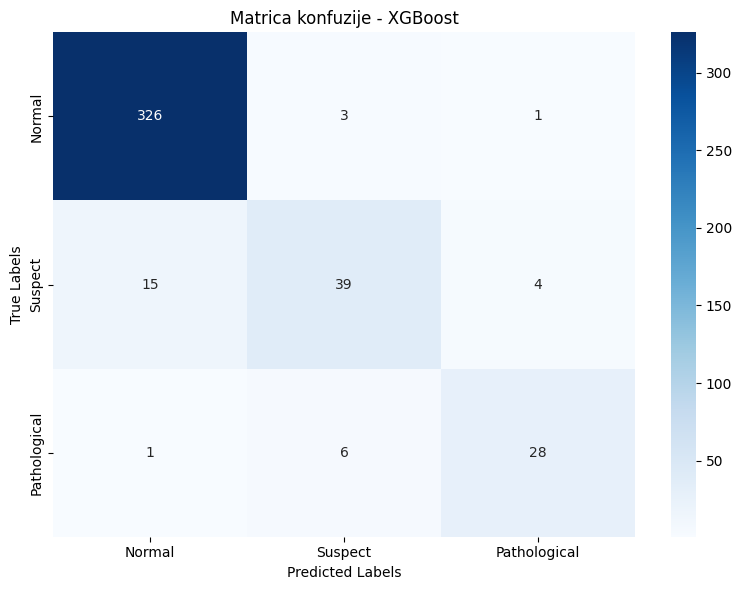

In [26]:
# Treniranje i evaluacija XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_metrics = train_and_eval_my_model(
    xgb_model, X_train, X_test, y_train, y_test, model_name="XGBoost"
 )
model_results.append(xgb_metrics)

## 6. Tuning hiperparametara

Nakon inicijalne evaluacije modela, sledeći korak je optimizacija hiperparametara kako bismo dodatno poboljšali performanse modela.

In [27]:
# Optimizacija hiperparametara za Random Forest bez leakage-a (SMOTE unutar CV foldova)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

rf_pipe = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif)),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'selector__k': [8, 10, 12],
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [2, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train_winsorized, y_train_shifted)

print("Najbolji hiperparametri za Random Forest (leakage-free):")
print(grid_search.best_params_)
print("Najbolji CV skor (f1_macro):", round(grid_search.best_score_, 4))

Najbolji hiperparametri za Random Forest (leakage-free):
{'rf__max_depth': 20, 'rf__min_samples_split': 2, 'rf__n_estimators': 100, 'selector__k': 12}
Najbolji CV skor (f1_macro): 0.8641


In [28]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_rf_pipeline = grid_search.best_estimator_

# CV procena najboljeg leakage-free pipeline modela
cv_scores = cross_val_score(
    best_rf_pipeline,
    X_train_winsorized,
    y_train_shifted,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print(f"Prosecan CV F1-macro (pipeline): {np.mean(cv_scores):.4f}")
print(f"Standardna devijacija: {np.std(cv_scores):.4f}")

# Finalni fit nad celim trening skupom i evaluacija na hold-out testu
best_rf_pipeline.fit(X_train_winsorized, y_train_shifted)
y_pred_best_rf = best_rf_pipeline.predict(X_test_winsorized)

from sklearn.metrics import classification_report, accuracy_score, f1_score
print("\nHold-out evaluacija leakage-free RF pipeline modela:")
print(classification_report(y_test_shifted, y_pred_best_rf))
print("Accuracy:", round(accuracy_score(y_test_shifted, y_pred_best_rf), 4))
print("F1-macro:", round(f1_score(y_test_shifted, y_pred_best_rf, average='macro'), 4))

# Za SHAP/LIME i vizuelizaciju stabla koristimo interpretabilni RF treniran ranije
best_rf_model = random_forest

Prosecan CV F1-macro (pipeline): 0.8641
Standardna devijacija: 0.0214

Hold-out evaluacija leakage-free RF pipeline modela:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       330
           1       0.75      0.67      0.71        58
           2       0.89      0.91      0.90        35

    accuracy                           0.92       423
   macro avg       0.86      0.85      0.86       423
weighted avg       0.92      0.92      0.92       423

Accuracy: 0.922
F1-macro: 0.8566


## 7. Evaluacija modela (ROC/AUC)


ROC krive za leakage-free RF pipeline:


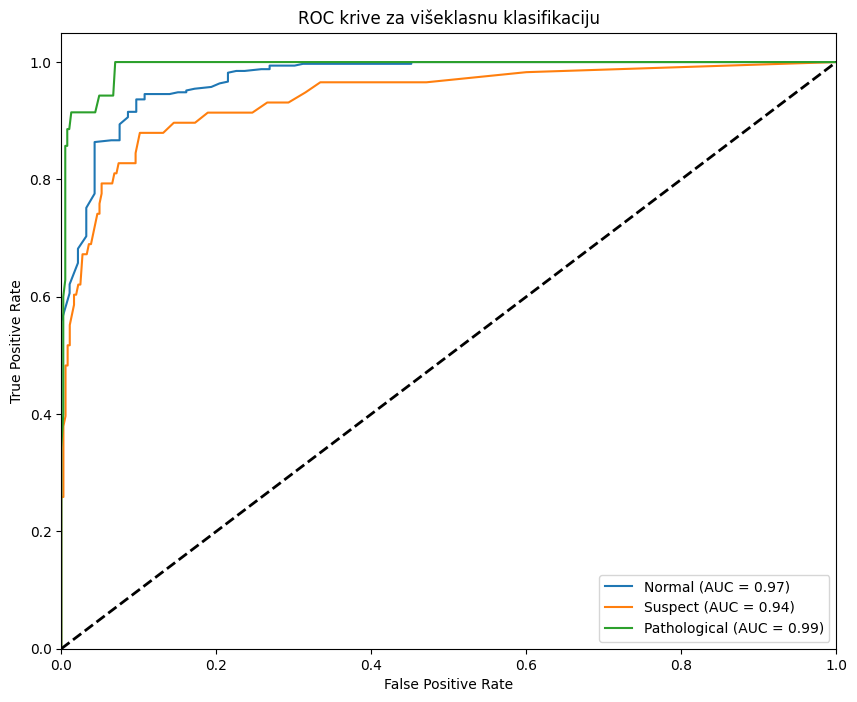

ROC krive za XGBoost:


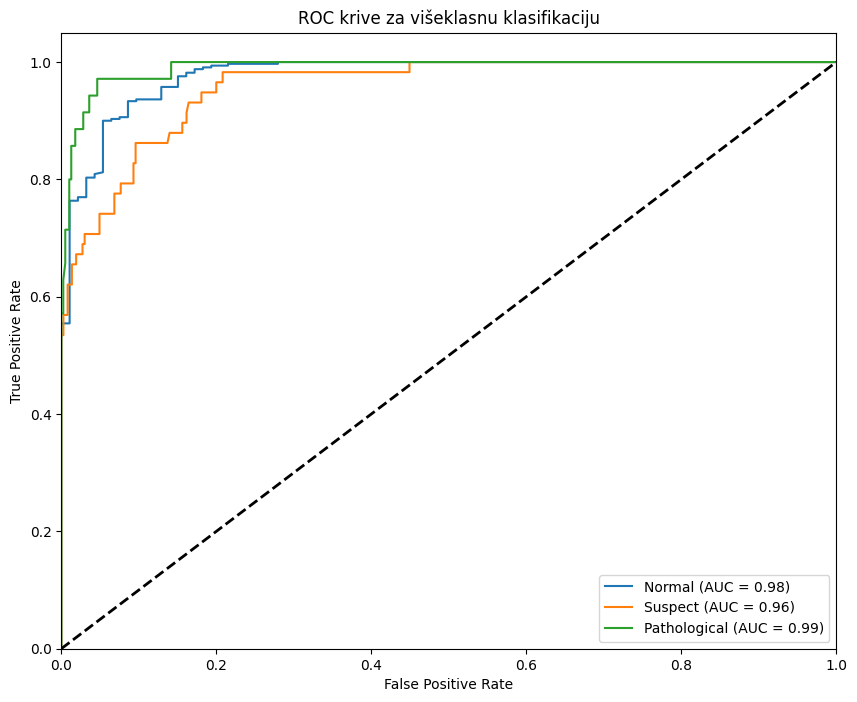

In [29]:
def plot_roc_auc_multiclass(model, X_eval, y_eval, class_names):
    from sklearn.metrics import roc_curve, auc
    from sklearn.preprocessing import label_binarize
    import matplotlib.pyplot as plt
    import numpy as np

    y_eval_bin = label_binarize(y_eval, classes=np.arange(len(class_names)))
    y_score = model.predict_proba(X_eval)

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(y_eval_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(10, 8))
    for i in range(len(class_names)):
        plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC krive za višeklasnu klasifikaciju')
    plt.legend(loc="lower right")
    plt.show()

class_names = ["Normal", "Suspect", "Pathological"]

print("ROC krive za leakage-free RF pipeline:")
plot_roc_auc_multiclass(best_rf_pipeline, X_test_winsorized, y_test_shifted, class_names)

print("ROC krive za XGBoost:")
plot_roc_auc_multiclass(xgb_model, X_test, y_test, class_names)

## 8. Interpretacija rezultata

U ovom odeljku ćemo analizirati značajke modela i vizualizovati odluke jednog stabla iz Random Forest modela.

Značajke Random Forest modela:


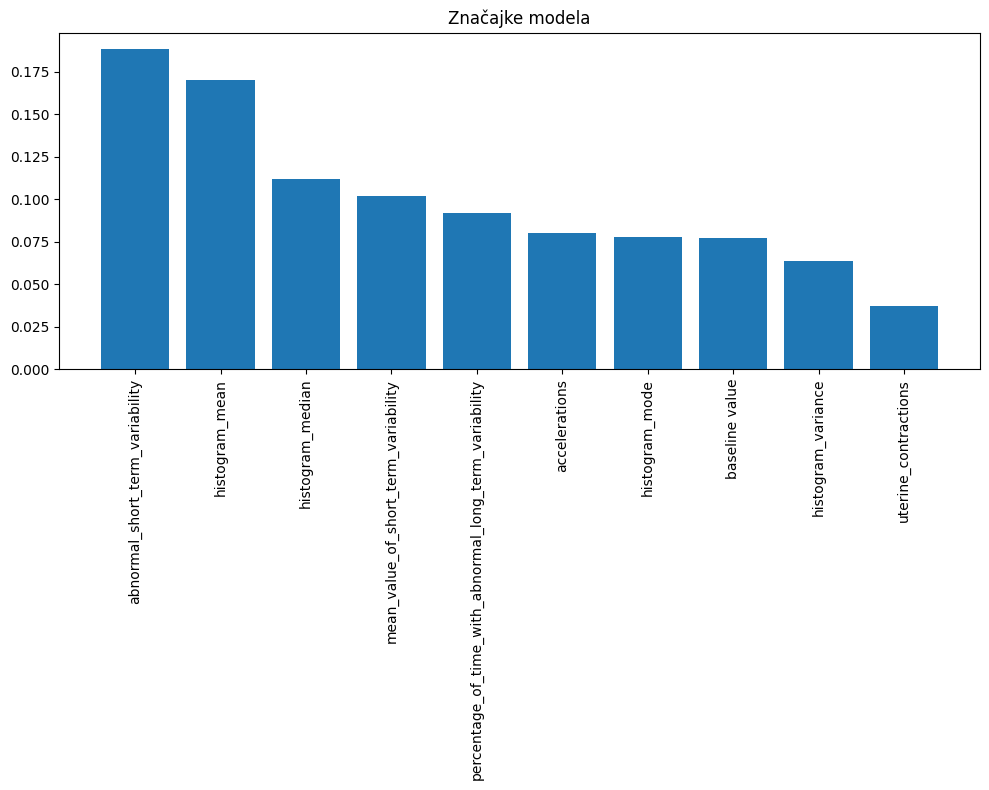

Vizualizacija prvog stabla iz Random Forest modela:


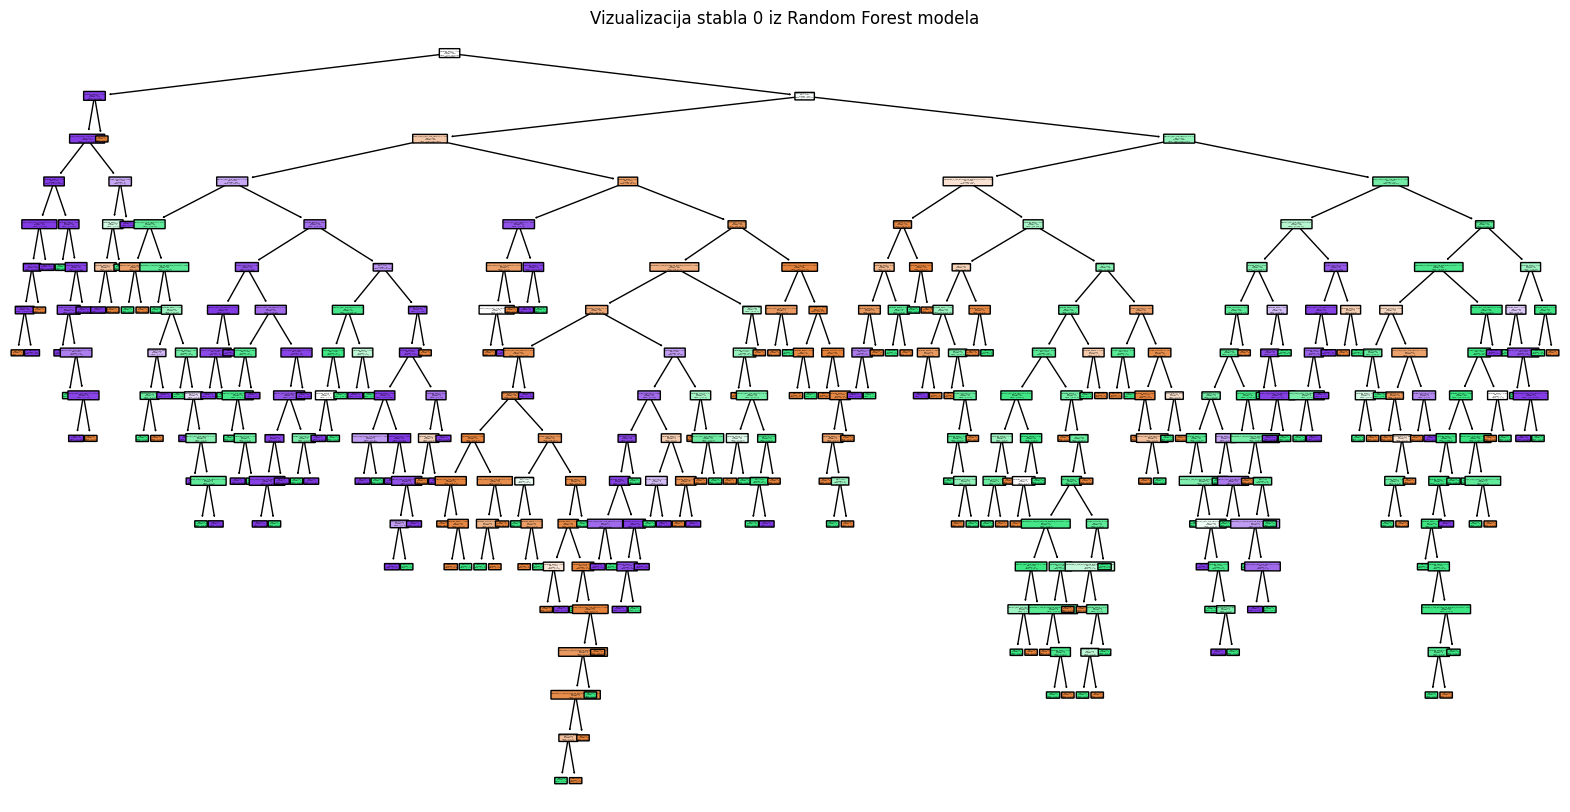

In [30]:
def draw_coef(model, X_train_df, model_type):
    import matplotlib.pyplot as plt
    import numpy as np

    if model_type == "linear":
        importance = model.coef_[0]
    elif model_type == "tree":
        importance = model.feature_importances_
    else:
        raise ValueError("Nepoznat tip modela. Koristite 'linear' ili 'tree'.")

    indices = np.argsort(importance)[::-1]
    features = X_train_df.columns

    plt.figure(figsize=(10, 8))
    plt.title("Značajke modela")
    plt.bar(range(len(importance)), importance[indices], align="center")
    plt.xticks(range(len(importance)), [features[i] for i in indices], rotation=90)
    plt.tight_layout()
    plt.show()

print("Značajke Random Forest modela:")
draw_coef(best_rf_model, X_train, model_type="tree")

def print_random_forest_tree(idx=0):
    from sklearn.tree import plot_tree
    import matplotlib.pyplot as plt

    plt.figure(figsize=(20, 10))
    plot_tree(
        best_rf_model.estimators_[idx],
        filled=True,
        feature_names=X_train.columns,
        class_names=class_names,
        rounded=True
    )
    plt.title(f"Vizualizacija stabla {idx} iz Random Forest modela")
    plt.show()

print("Vizualizacija prvog stabla iz Random Forest modela:")
print_random_forest_tree(idx=0)

## 9. Detaljna analiza interpretabilnosti (SHAP vrednosti)

Iako Feature Importance pokazuje koji su faktori bitni, SHAP (SHapley Additive exPlanations) nam pomaže da razumemo KAKO i u kom SMERU ti faktori utiču na svaku pojedinačnu predikciju.

SHAP Summary Plot za klasu: Pathological (Klasa 2)


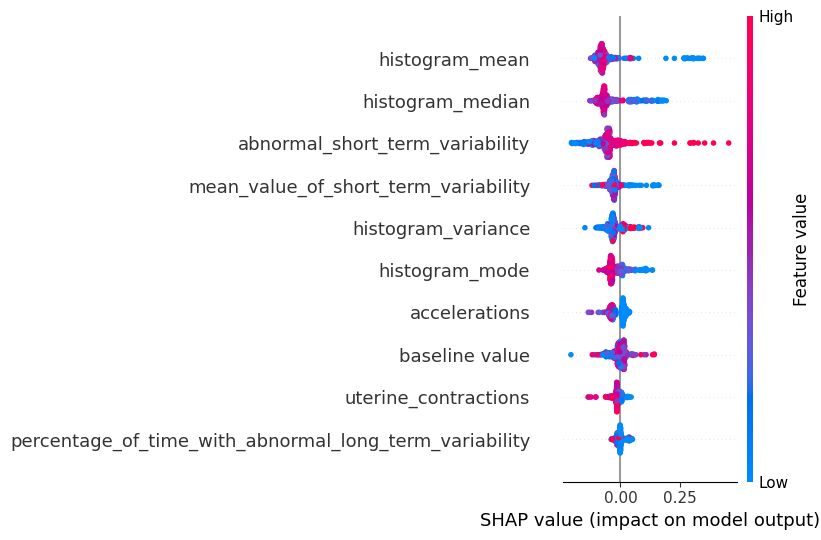

In [31]:
import shap
import numpy as np

explainer = shap.TreeExplainer(best_rf_model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_to_plot = shap_values[2]
elif len(shap_values.shape) == 3:
    shap_to_plot = shap_values[:, :, 2]
else:
    shap_to_plot = shap_values

print("SHAP Summary Plot za klasu: Pathological (Klasa 2)")
shap.summary_plot(shap_to_plot, X_test, plot_type="dot")

Na ovom grafikonu, crvena boja označava visoke vrednosti parametra, a plava niske. Na primer, ako vidimo da visoke vrednosti 'prolongued_decelerations' pomeraju predikciju udesno, to potvrđuje da je to ključni indikator za patološko stanje.

In [32]:
import lime
from lime import lime_tabular
import pandas as pd
from IPython.display import display, HTML

explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    class_names=['Normal', 'Suspect', 'Pathological'],
    mode='classification'
)

pathological_indices = np.where(y_test == 2)[0]
sample_idx = pathological_indices[0]

exp = explainer.explain_instance(
    X_test.values[sample_idx],
    best_rf_model.predict_proba,
    num_features=10,
    labels=[2]
)

print(f"LIME objašnjenje za uzorak br. {sample_idx} (Stvarna klasa: Pathological)")
display(HTML(exp.as_html()))

lime_df = pd.DataFrame(exp.as_list(label=2), columns=['Feature', 'Contribution'])
display(lime_df)

LIME objašnjenje za uzorak br. 2 (Stvarna klasa: Pathological)


,Feature,Contribution
0,histogram_median > 0.71,-0.064648
1,histogram_mean > 0.76,-0.058042
2,mean_value_of_short_term_variability <= -1.17,0.045969
3,histogram_mode > 0.70,-0.036944
4,-0.16 < abnormal_short_term_variability <= 0.82,-0.031477
5,accelerations <= -0.83,-0.020293
6,-1.49 < uterine_contractions <= -0.47,0.014687
7,baseline value > 1.00,0.014464
8,histogram_variance <= -0.80,0.006707
9,-0.27 < percentage_of_time_with_abnormal_long_...,-0.004379


In [33]:
# Zbirni prikaz rezultata svih modela (automatski iz realnih rezultata)
if 'model_results' in globals() and len(model_results) > 0:
    df_rezultati = pd.DataFrame(model_results)
    display(df_rezultati.sort_values(by="Accuracy", ascending=False))
else:
    print("Nisu pronađeni rezultati modela. Pokreni sekciju treniranja modela.")

,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted),F1-Score (Macro)
3,XGBoost,0.929078,0.925256,0.929078,0.925961,0.843206
1,Random Forest,0.919622,0.915934,0.919622,0.917095,0.844303
2,SVM,0.846336,0.884811,0.846336,0.858828,0.745292
0,Logistic Regression,0.827423,0.869315,0.827423,0.841004,0.733447


## 10. Zaključak

Na osnovu analize i evaluacije modela, Random Forest se pokazao kao najbolji model za klasifikaciju fetalnog zdravlja, sa najvišim vrednostima AUC i preciznošću u poređenju sa ostalim modelima. Njegova sposobnost da se nosi sa nelinearnim odnosima i značajkama koje nisu normalno distribuirane doprinela je superiornim performansama.

Primena SMOTE tehnike za balansiranje klasa bila je ključna za poboljšanje performansi modela. Originalni skup podataka bio je neuravnotežen, sa značajno manjim brojem primera za klase "Suspect" i "Pathological" u poređenju sa klasom "Normal". SMOTE je omogućio generisanje sintetičkih primera za manje zastupljene klase, čime je model bolje naučio da razlikuje sve klase.

Winsorizacija je korišćena za tretiranje autlajera u podacima. Ova tehnika je pomogla u smanjenju uticaja ekstremnih vrednosti koje bi mogle negativno uticati na performanse modela, posebno kod algoritama osetljivih na skale podataka.

Analiza značajki pokazala je da su određene karakteristike CTG signala, poput "prolongued_decelerations", bile najvažnije za dijagnozu. Ove značajke pružaju ključne informacije o stanju fetusa i omogućavaju lekarima da donesu informisane odluke.

Ovaj projekat pokazuje kako primena naprednih tehnika mašinskog učenja i obrade podataka može doprineti poboljšanju dijagnostike i brige o zdravlju fetusa.